# 区分別出願件数集計

`goods-and-service-name-and-code` から区分番号を抽出し、**企業 × 出願年 × 区分** で件数を集計するノートブック。

In [1]:
import os

import pandas as pd
from utils.db import get_conn, DB_CONFIG

print('DB設定を読み込みました:', DB_CONFIG['host'], DB_CONFIG['dbname'])

DB設定を読み込みました: 172.18.106.203 trademark_db


---

## 1. ユーティリティ関数の読み込み

`trademark_utils.py` から以下の関数をインポートする。

| 関数 | 説明 |
|---|---|
| `parse_filing_date(text)` | 出願日文字列（和暦）→ `datetime.date` |
| `extract_classes(text)` | 指定商品・役務文字列 → 区分番号の整数リスト |

In [2]:
from utils.trademark_utils import parse_filing_date, extract_classes, year_like_patterns

print('utils.trademark_utils を読み込みました')

utils.trademark_utils を読み込みました


---

## 2. データ取得

対象企業の `company_id` と対象年（西暦、単年/複数年/範囲）を入力してからセルを実行してください。  
どちらかが未入力の場合はエラーで停止します。

In [3]:
# ===== 検索条件を入力 =====
target_company_id = 131094   # 例: 131094
target_years       = [2018, 2019, 2020]   # 例: 2020（単年） / [2018, 2019, 2020]（複数年） / range(2018, 2021)（範囲）
# ==========================

# --- 入力値の正規化 ---
if isinstance(target_years, (int,)):
    target_years = [target_years]
elif isinstance(target_years, range):
    target_years = list(target_years)
else:
    target_years = sorted(set(target_years))

# --- 入力値の検証 ---
_errors = []
if target_company_id is None:
    _errors.append('  • target_company_id が未設定です（整数で入力してください）')
if not target_years:
    _errors.append('  • target_years が未設定です（西暦4桁の整数、またはそのリスト/rangeで入力してください）')
if _errors:
    raise ValueError(
        '以下の入力が不足しています。値を設定してからセルを再実行してください。\n'
        + '\n'.join(_errors)
    )

# 表示用ラベル（連続年は範囲表記、それ以外は列挙）
def _years_label(years):
    years = sorted(years)
    if len(years) == 1:
        return f'{years[0]}年'
    if years == list(range(years[0], years[-1] + 1)):
        return f'{years[0]}〜{years[-1]}年'
    return '・'.join(f'{y}年' for y in years)

years_label = _years_label(target_years)

print(f'対象企業ID : {target_company_id}')
print(f'対象年     : {years_label}')

対象企業ID : 131094
対象年     : 2018〜2020年


In [4]:
# company_id と対象年（LIKE で粗く絞り込み）でフィルタして取得
_year_patterns = year_like_patterns(target_years)

with get_conn() as conn:
    df_raw = pd.read_sql("""
        SELECT
            "right-holder-group-identification-number"  AS company_id,
            "right-holder-group-name"                   AS company_name,
            "filing-date"                               AS filing_date_raw,
            "goods-and-service-name-and-code"           AS goods_and_service
        FROM trademark_db
        WHERE "goods-and-service-name-and-code"               IS NOT NULL
          AND "filing-date"                                    IS NOT NULL
          AND "right-holder-group-identification-number"      = %(company_id)s
          AND "filing-date"                                    LIKE ANY(%(patterns)s)
    """, conn, params={'company_id': target_company_id, 'patterns': _year_patterns})

if df_raw.empty:
    raise ValueError(
        f'company_id={target_company_id}、{years_label} の出願データが見つかりませんでした。'
        ' company_id または対象年を確認してください。'
    )

# LIKE は年の絞り込みの粗いフィルタなので、filing_date をパースして念のため厳密に再確認
df_raw['filing_date'] = df_raw['filing_date_raw'].apply(parse_filing_date)
df_raw['filing_year'] = df_raw['filing_date'].apply(lambda d: d.year if d else None)
df_raw = df_raw[df_raw['filing_year'].isin(target_years)].copy()

if df_raw.empty:
    raise ValueError(
        f'company_id={target_company_id}、{years_label} の出願データが見つかりませんでした。'
    )

company_name = df_raw['company_name'].iloc[0]
print(f'企業名   : {company_name}（ID: {target_company_id}）')
print(f'取得件数 : {len(df_raw):,} 件（{years_label}）')
df_raw.head(3)

C:\Users\k-fukuzawa\AppData\Local\Temp\ipykernel_14400\1683166812.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_raw = pd.read_sql("""


企業名   : 株式会社サンリオ（ID: 131094）
取得件数 : 1,767 件（2018〜2020年）


,company_id,company_name,filing_date_raw,goods_and_service,filing_date,filing_year
0,131094,株式会社サンリオ,平成３０年１月９日（２０１８．１．９）,第４１類 ゴルフの興行の企画・運営又は開催，相撲の興行の企画・運営又は開催，ボクシングの興...,2018-01-09,2018
1,131094,株式会社サンリオ,平成３０年１月９日（２０１８．１．９）,第４１類 ゴルフの興行の企画・運営又は開催，相撲の興行の企画・運営又は開催，ボクシングの興...,2018-01-09,2018
2,131094,株式会社サンリオ,平成３０年２月６日（２０１８．２．６）,第２５類 洋服，コート，セーター類，ワイシャツ類，寝巻き類，下着，水泳着，水泳帽，和服，ア...,2018-02-06,2018


---

## 3. 前処理

In [5]:
df = df_raw.copy()

# 区分番号リストを列に追加
df['class_list'] = df['goods_and_service'].apply(extract_classes)

# 区分抽出ゼロ件の確認
n_class_empty = df['class_list'].apply(len).eq(0).sum()
print(f'区分抽出ゼロ件: {n_class_empty:,} 件')

df.head(3)

区分抽出ゼロ件: 0 件


,company_id,company_name,filing_date_raw,goods_and_service,filing_date,filing_year,class_list
0,131094,株式会社サンリオ,平成３０年１月９日（２０１８．１．９）,第４１類 ゴルフの興行の企画・運営又は開催，相撲の興行の企画・運営又は開催，ボクシングの興...,2018-01-09,2018,[41]
1,131094,株式会社サンリオ,平成３０年１月９日（２０１８．１．９）,第４１類 ゴルフの興行の企画・運営又は開催，相撲の興行の企画・運営又は開催，ボクシングの興...,2018-01-09,2018,[41]
2,131094,株式会社サンリオ,平成３０年２月６日（２０１８．２．６）,第２５類 洋服，コート，セーター類，ワイシャツ類，寝巻き類，下着，水泳着，水泳帽，和服，ア...,2018-02-06,2018,[25]


In [6]:
# 1行1区分に展開
df_exploded = (
    df
    .explode('class_list')                   # 区分ごとに行を展開
    .dropna(subset=['class_list'])           # 区分なしは除外
    .rename(columns={'class_list': 'class_number'})
    .astype({'class_number': int, 'filing_year': int})
)

print(f'展開後件数: {len(df_exploded):,} 件')
df_exploded[['company_id', 'company_name', 'filing_year', 'class_number']].head(5)

展開後件数: 4,869 件


,company_id,company_name,filing_year,class_number
0,131094,株式会社サンリオ,2018,41
1,131094,株式会社サンリオ,2018,41
2,131094,株式会社サンリオ,2018,25
3,131094,株式会社サンリオ,2018,30
4,131094,株式会社サンリオ,2018,31


---

## 4. 集計：区分別出願件数

In [7]:
result = (
    df_exploded
    .groupby(['company_id', 'company_name', 'filing_year', 'class_number'])
    .size()
    .reset_index(name='application_count')
    .sort_values('class_number')
    .reset_index(drop=True)
)

print(f'{company_name}（{years_label}）  集計区分数: {len(result):,} 区分')
result

株式会社サンリオ（2018〜2020年）  集計区分数: 132 区分


,company_id,company_name,filing_year,class_number,application_count
0,131094,株式会社サンリオ,2018,1,32
1,131094,株式会社サンリオ,2019,1,21
2,131094,株式会社サンリオ,2020,1,17
3,131094,株式会社サンリオ,2019,2,27
4,131094,株式会社サンリオ,2020,2,20
...,...,...,...,...,...
127,131094,株式会社サンリオ,2018,44,22
128,131094,株式会社サンリオ,2020,44,19
129,131094,株式会社サンリオ,2018,45,20
130,131094,株式会社サンリオ,2019,45,28


---

## 5. ピボット表示

行 = 出願年、列 = 区分番号、値 = 出願件数

In [8]:
pivot = (
    result
    .pivot_table(
        index='filing_year',
        columns='class_number',
        values='application_count',
        aggfunc='sum',
        fill_value=0,
    )
)
pivot.columns = [f'第{c}類' for c in pivot.columns]

print(f'{company_name}（ID: {target_company_id}）の区分別出願件数')
pivot

株式会社サンリオ（ID: 131094）の区分別出願件数


,第1類,第2類,第3類,第4類,第5類,第6類,第7類,第8類,第9類,第10類,...,第36類,第37類,第38類,第39類,第40類,第41類,第42類,第43類,第44類,第45類
filing_year,,,,,,,,,,,,,,,,,,,,,
2018,32,30,52,29,41,35,28,48,62,32,...,26,18,18,30,26,65,30,33,22,20
2019,21,27,41,28,37,37,32,52,62,31,...,35,24,29,30,32,44,32,33,25,28
2020,17,20,34,20,33,30,15,40,49,28,...,28,17,25,19,21,47,26,37,19,24


---

## 6. 区分別出願件数ヒストグラム

第1類〜第45類を横軸に、出願件数を縦軸に表示する。出願ゼロの区分も含めて全45区分を描画する。

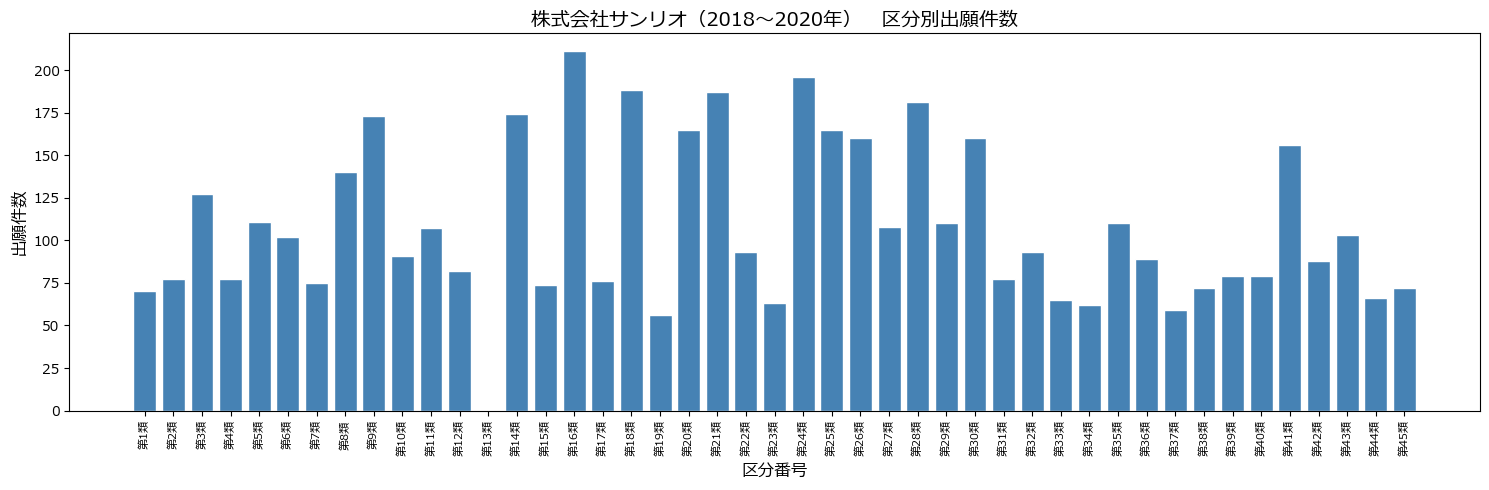

In [9]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'Meiryo'  # Windows 日本語フォント

# 第1〜45類すべてを軸に並べ、出願なしは0で埋める（複数年の場合は年を合算）
all_classes = range(1, 46)
hist_data = (
    result
    .groupby('class_number')['application_count'].sum()
    .reindex(all_classes, fill_value=0)
)

fig, ax = plt.subplots(figsize=(15, 5))
bars = ax.bar(hist_data.index, hist_data.values, color='steelblue', edgecolor='white')

ax.set_xlabel('区分番号', fontsize=12)
ax.set_ylabel('出願件数', fontsize=12)
ax.set_title(f'{company_name}（{years_label}）　区分別出願件数', fontsize=14)
ax.set_xticks(list(all_classes))
ax.set_xticklabels([f'第{c}類' for c in all_classes], rotation=90, fontsize=8)
ax.yaxis.get_major_locator().set_params(integer=True)  # y軸を整数刻みに

plt.tight_layout()
plt.show()

---

## 7. CSV 出力（任意）

In [10]:
_year_suffix = f'{target_years[0]}' if len(target_years) == 1 else f'{target_years[0]}-{target_years[-1]}'
out_path = f'output/class_filing_{target_company_id}_{_year_suffix}.csv'
os.makedirs('output', exist_ok=True)
result.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'保存しました: {out_path}')

保存しました: output/class_filing_131094_2018-2020.csv
